In [1]:
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2


import kagglehub

In [2]:
# Downloading Dataset directly from Kaggle by URL
dataset = kagglehub.dataset_download("msambare/fer2013")
print(dataset)

Using Colab cache for faster access to the 'fer2013' dataset.
/kaggle/input/fer2013


In [3]:
xtrain = dataset+"/train"
xtest = dataset+"/test"

IMG_SIZE = 48
BATCH_SIZE = 64

In [4]:
xtrain_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

xtest_datagen = ImageDataGenerator(
    rescale=1./255
)
xtrain_data = xtrain_datagen.flow_from_directory(
    xtrain,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

xtest_data = xtest_datagen.flow_from_directory(
    xtest,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
model = Sequential([Conv2D(32,(3,3),
                           activation='relu',input_shape=(48,48,1)),
                    BatchNormalization(),
                    MaxPooling2D(2,2),Conv2D(64,(3,3),activation='relu'),
                    BatchNormalization(),
                    MaxPooling2D(2,2),Conv2D(128,(3,3),activation='relu'),
                    BatchNormalization(),
                    MaxPooling2D(2,2),
                    Flatten(),
                    Dense(128, activation='relu'),
                    Dropout(0.5),
                    Dense(7, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
loss, accuracy = model.evaluate(xtest_data)

print("Loss:", loss)
print("Accuracy:", accuracy)

113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 233ms/step - accuracy: 0.2320 - loss: 1.9387
Loss: 1.9386556148529053
Accuracy: 0.2319587618112564


In [8]:
emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

In [9]:
model= Sequential()
model.add(Conv2D(32,(3,3),
activation="relu",input_shape=(48,48,1)))
model.add( MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64,activation="relu"))
model.add(Dense(7,activation="softmax"))

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.fit(
    xtrain_data,
    validation_data=xtest_data,
    epochs=70
)

Epoch 1/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 123s 267ms/step - accuracy: 0.2978 - loss: 1.7313 - val_accuracy: 0.3734 - val_loss: 1.6171
Epoch 2/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.3474 - loss: 1.6617 - val_accuracy: 0.4179 - val_loss: 1.5476
Epoch 3/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.3591 - loss: 1.6379 - val_accuracy: 0.3915 - val_loss: 1.5705
Epoch 4/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.3718 - loss: 1.6085 - val_accuracy: 0.4344 - val_loss: 1.4922
Epoch 5/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.3766 - loss: 1.5961 - val_accuracy: 0.4359 - val_loss: 1.4791
Epoch 6/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.3882 - loss: 1.5697 - val_accuracy: 0.4441 - val_loss: 1.4590
Epoch 7/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 85ms/step - accuracy: 0.3944 - loss: 1.5546 - val_accuracy: 0.4492 - val_loss: 1.4478
Epoch 8/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.3990 - loss: 1.5451 

In [12]:
p=model.predict(xtest_data)
p

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step


array([[0.29564723, 0.00342826, 0.21185507, ..., 0.2657074 , 0.05685421,
        0.1585719 ],
       [0.10304059, 0.00269609, 0.426648  , ..., 0.05181932, 0.2875968 ,
        0.07324255],
       [0.3089612 , 0.00238407, 0.15955663, ..., 0.10756724, 0.24531767,
        0.02173896],
       ...,
       [0.18800749, 0.03455473, 0.08995976, ..., 0.04111578, 0.15371792,
        0.01168268],
       [0.10655816, 0.00138375, 0.28078458, ..., 0.06685618, 0.09400029,
        0.43379334],
       [0.27994922, 0.01063643, 0.14866576, ..., 0.19659881, 0.16496938,
        0.15772893]], dtype=float32)

In [13]:
model.save("emotion_model.h5")

In [14]:
batch_size = xtest_data.batch_size
image_index = 1800

batch_number = image_index // batch_size
index = image_index % batch_size

for i in range(batch_number + 1):
    batch = next(xtest_data)

images = batch[0]

img = images[index]

pred = model.predict(img.reshape(1,48,48,1))

print(emotion_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
Surprise


In [15]:
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow

model = load_model("emotion_model.h5")

In [16]:

face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)


Enter image or video: image
Enter image URL: 
Detected Emotion: Happy
(600, 600, 3)

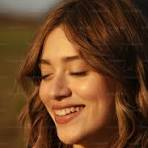

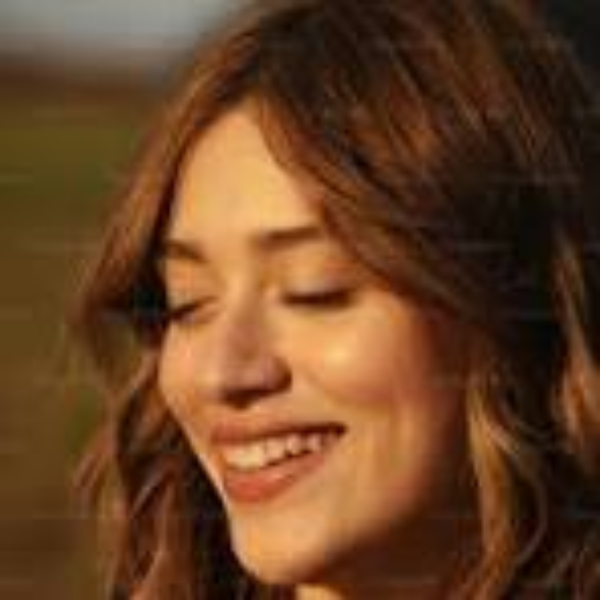

In [17]:

import urllib.request

choose = input("Enter image or video: ").lower()

if choose == "image":

    image_url = input("Enter image URL: ")

    urllib.request.urlretrieve(image_url, "temp.jpg")

    img = cv2.imread("temp.jpg")
    img = cv2.resize(img, (600, 600))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_classifier.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        print("No face detected")

    else:
        for (x, y, w, h) in faces:

            roi_gray = gray[y:y+h, x:x+w]
            roi_gray = cv2.resize(roi_gray, (48, 48))

            roi = roi_gray.astype("float") / 255.0
            roi = np.reshape(roi, (1, 48, 48, 1))

            prediction = model.predict(roi, verbose=0)

            label = emotion_labels[np.argmax(prediction)]

            print("Detected Emotion:", label)

    print(img.shape)
    cv2_imshow(img)

elif choose == "video":

    video_url = input("Enter video URL: ").strip()

    urllib.request.urlretrieve(video_url, "temp_video.mp4")

    video = cv2.VideoCapture("temp_video.mp4")

    face_found = False

    while True:

        ret, frame = video.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_classifier.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=3,
            minSize=(30, 30)
        )

        for (x, y, w, h) in faces:

            roi_gray = gray[y:y+h, x:x+w]
            roi_gray = cv2.resize(roi_gray, (48, 48))

            roi = roi_gray.astype("float") / 255.0
            roi = np.reshape(roi, (1, 48, 48, 1))

            prediction = model.predict(roi, verbose=0)

            label = emotion_labels[np.argmax(prediction)]

            print("Detected Emotion:", label)

            face_found = True
            break

        if face_found:
            break

    video.release()

else:
    print("Invalid choice")